In [7]:
import pandas as pd
df1 = pd.read_excel('_h_batch_process_data.xlsx')
df2 = pd.read_excel('_h_batch_production_data.xlsx')


In [13]:
df1.columns

Index(['Batch_ID', 'Time_Minutes', 'Phase', 'Temperature_C', 'Pressure_Bar',
       'Humidity_Percent', 'Motor_Speed_RPM', 'Compression_Force_kN',
       'Flow_Rate_LPM', 'Power_Consumption_kW', 'Vibration_mm_s'],
      dtype='str')

In [14]:
df2.columns

Index(['Batch_ID', 'Granulation_Time', 'Binder_Amount', 'Drying_Temp',
       'Drying_Time', 'Compression_Force', 'Machine_Speed', 'Lubricant_Conc',
       'Moisture_Content', 'Tablet_Weight', 'Hardness', 'Friability',
       'Disintegration_Time', 'Dissolution_Rate', 'Content_Uniformity'],
      dtype='str')

In [16]:
df2.isnull().sum()

Batch_ID               0
Granulation_Time       0
Binder_Amount          0
Drying_Temp            0
Drying_Time            0
Compression_Force      0
Machine_Speed          0
Lubricant_Conc         0
Moisture_Content       0
Tablet_Weight          0
Hardness               0
Friability             0
Disintegration_Time    0
Dissolution_Rate       0
Content_Uniformity     0
dtype: int64

In [19]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Granulation_Time     60 non-null     int64  
 1   Binder_Amount        60 non-null     float64
 2   Drying_Temp          60 non-null     int64  
 3   Drying_Time          60 non-null     int64  
 4   Compression_Force    60 non-null     float64
 5   Machine_Speed        60 non-null     int64  
 6   Lubricant_Conc       60 non-null     float64
 7   Moisture_Content     60 non-null     float64
 8   Tablet_Weight        60 non-null     float64
 9   Hardness             60 non-null     int64  
 10  Friability           60 non-null     float64
 11  Disintegration_Time  60 non-null     float64
 12  Dissolution_Rate     60 non-null     float64
 13  Content_Uniformity   60 non-null     float64
dtypes: float64(9), int64(5)
memory usage: 6.7 KB


In [18]:
df2.drop('Batch_ID',inplace=True,axis=1)

In [21]:
X = df2.drop(['Hardness','Content_Uniformity','Dissolution_Rate'],axis=1)
y = df2[['Hardness','Content_Uniformity','Dissolution_Rate']]

<Axes: >

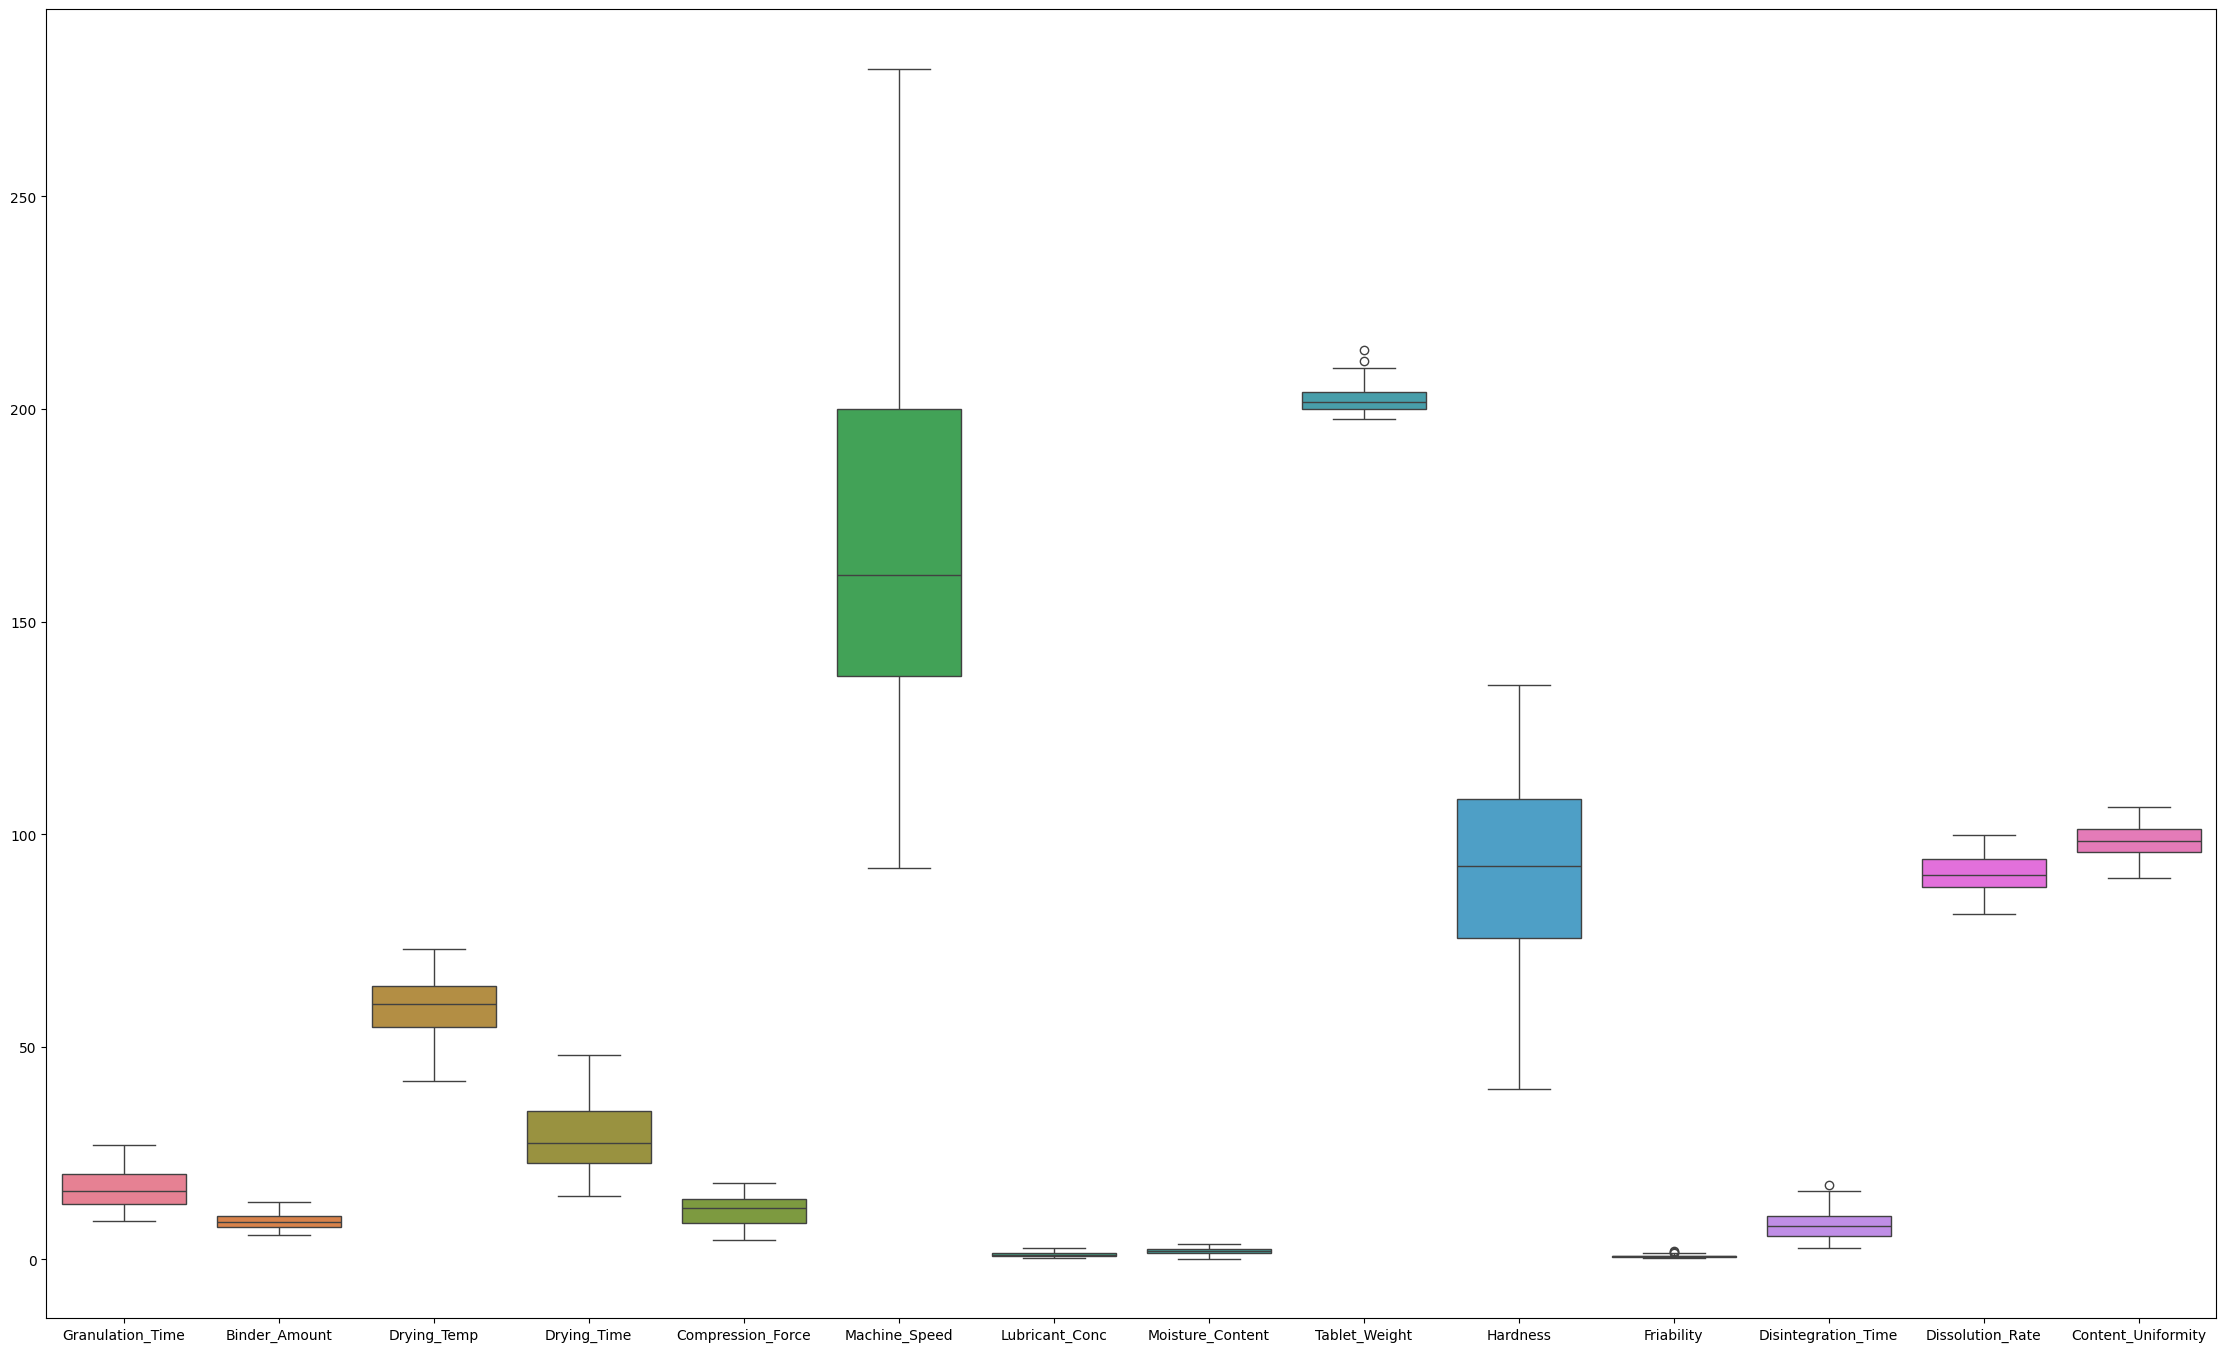

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(28,17))
sns.boxplot(df2)

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
model = MultiOutputRegressor(RandomForestRegressor())
model.fit(X_train_scaled,y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestRegressor()
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least oneval

In [35]:
y_pred = model.predict(X_test_scaled)
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.9821078434692673
0.8298611111110926
1.79241013888888
